This program performs the following tasks:
1. Imports the required packages, dependencies and libraries
2. Initializes the test case dataset
3. Runs tasks to evaluate each pLM/model (through "adapters")
4. Returns the error and AURPC of each model
# Step 1: Initialize required packages and datasets

## 1.1 Prepare the envs and dependencies overall

In [1]:
import os
import subprocess
import sys

print("Setting up project environments...")
os.makedirs("./envs", exist_ok=True)
os.makedirs("evaluation_outputs", exist_ok=True)

base_pkgs = [
    "python=3.10",
    "pytorch",
    "torchvision",
    "torchaudio",
    "transformers",
    "pandas",
    "numpy",
    "tqdm",
    "cd-hit",
    "hmmer",
]
conda_args = ["-c", "pytorch", "-c", "conda-forge", "-c", "bioconda", "-y", "-q"]


def run_silent_cmd(cmd, description):
  """Runs command. If it fails, prints error output and stops."""
  try:
    subprocess.run(cmd, check=True, text=True)
  except subprocess.CalledProcessError as e:
    print(f"\nERROR: Failed while {description}")
    sys.exit(1)


def setup_conda_env(env_name, extra_pkgs=None):
  env_path = os.path.abspath(f"./envs/{env_name}")
  python_exec = os.path.join(env_path, "bin", "python")
  pip_exec = os.path.join(env_path, "bin", "pip")

  if not os.path.exists(python_exec):
    print(f"Creating {env_name} environment (this may take a while)...")
    pkgs = base_pkgs + (extra_pkgs if extra_pkgs else [])

    conda_cmd = ["conda", "create", "--prefix", env_path] + pkgs + conda_args
    run_silent_cmd(conda_cmd, f"creating Conda environment {env_name}")

    pip_cmd = [pip_exec, "install", "-qqq", "abnumber"]
    run_silent_cmd(pip_cmd, f"installing abnumber in {env_name}")
  else:
    print(f"{env_name} environment already exists.")
  return env_path, python_exec, pip_exec


# 0. Main Project Environment
print("Setting up Main Project environment...")
env_main, main_python, main_pip = setup_conda_env("main_env")

# 1. ESM-2
print("Setting up ESM-2 environment...")
env_esm, esm_python, _ = setup_conda_env("plm_esm")

# 2. ProtT5
print("Setting up ProtT5 environment...")
env_prott5, prott5_python, _ = setup_conda_env(
    "plm_prott5", ["sentencepiece", "protobuf"]
)

# 3. Ankh
print("Setting up Ankh environment...")
env_ankh, ankh_python, ankh_pip = setup_conda_env(
    "plm_ankh", ["sentencepiece", "protobuf"]
)
print("Installing 'ankh' package via pip in plm_ankh...")
run_silent_cmd([ankh_pip, "install", "-qqq", "ankh"], "installing ankh via pip")

print("Ensuring PyTorch >= 2.6 across model environments...")
for env_name in ["plm_esm", "plm_prott5", "plm_ankh"]:
  print(f"Upgrading PyTorch in {env_name}...")
  pip_path = os.path.abspath(f"./envs/{env_name}/bin/pip")
  upgrade_cmd = [
      pip_path,
      "install",
      "-qqq",
      "--upgrade",
      "torch",
      "torchvision",
      "torchaudio",
  ]
  run_silent_cmd(upgrade_cmd, f"upgrading PyTorch in {env_name}")

print(
    "Installing main project dependencies (gdown, PyDrive2, Spark,"
    " Findspark, etc.) into main_env..."
)
main_pip_cmd = [
    main_pip,
    "install",
    "-qqq",
    "gdown",
    "tabulate",
    "datasets",
    "scikit-learn",
    "abnumber",
    "findspark",
    "pyspark<4.0",
    "delta-spark<4.0",
    "PyDrive2",
]
run_silent_cmd(main_pip_cmd, "installing main dependencies")

print("\nReady! All environments created under ./envs/:")
print(f"  - Main Python Executable: {main_python}")
print(f"  - ESM Python Executable:  {esm_python}")
print(f"  - ProtT5 Python Executable: {prott5_python}")
print(f"  - Ankh Python Executable:   {ankh_python}")

Setting up project environments...
Setting up Main Project environment...
main_env environment already exists.
Setting up ESM-2 environment...
plm_esm environment already exists.
Setting up ProtT5 environment...
plm_prott5 environment already exists.
Setting up Ankh environment...
plm_ankh environment already exists.
Installing 'ankh' package via pip in plm_ankh...
Ensuring PyTorch >= 2.6 across model environments...
Upgrading PyTorch in plm_esm...
Upgrading PyTorch in plm_prott5...
Upgrading PyTorch in plm_ankh...
Installing main project dependencies (gdown, PyDrive2, Spark, Findspark, etc.) into main_env...

Ready! All environments created under ./envs/:
  - Main Python Executable: /mnt/natanon/EvalTests/envs/main_env/bin/python
  - ESM Python Executable:  /mnt/natanon/EvalTests/envs/plm_esm/bin/python
  - ProtT5 Python Executable: /mnt/natanon/EvalTests/envs/plm_prott5/bin/python
  - Ankh Python Executable:   /mnt/natanon/EvalTests/envs/plm_ankh/bin/python


In [2]:
import os
import pandas as pd
import numpy as np

output_dir = "evaluation_outputs"
asd_data_path = "./asd_data"

if not os.path.exists(asd_data_path):
    raise FileNotFoundError(f"Local path '{asd_data_path}' not found. Please place your downloaded ASD dataset folder there.")

print("Scanning and securely loading valid ASD dataset files...")
data_frames = []

for root, dirs, files in os.walk(asd_data_path):
    # Skip delta log internal directories
    if "_delta_log" in root:
        continue
        
    for file in files:
        # Skip hidden files, system files, and checksum files
        if file.startswith('.') or file.endswith('.crc'):
            continue
        
        file_path = os.path.join(root, file)
        
        # Verify parquet format via header/footer magic bytes ('PAR1')
        if file.endswith('.parquet') or 'part-' in file:
            try:
                with open(file_path, "rb") as f:
                    header = f.read(4)
                    f.seek(-4, os.SEEK_END)
                    footer = f.read(4)
                if header == b'PAR1' and footer == b'PAR1':
                    df_part = pd.read_parquet(file_path)
                    data_frames.append(df_part)
            except Exception:
                pass
        
        # Fallback check for tabular CSV/TSV files
        elif file.endswith('.csv') or file.endswith('.tsv'):
            try:
                sep = '\t' if file.endswith('.tsv') else ','
                df_part = pd.read_csv(file_path, sep=sep)
                if len(df_part.columns) > 1:
                    data_frames.append(df_part)
            except Exception:
                pass

if not data_frames:
    raise RuntimeError(
        f"No valid Parquet or CSV data files were found inside '{asd_data_path}'. "
        "Please check your dataset directory structure."
    )

df_asd = pd.concat(data_frames, ignore_index=True)

# --- SAFE PARSING FOR FUZZY & BOOL DATA ---
h_col = 'heavy_chain_seq' if 'heavy_chain_seq' in df_asd.columns else df_asd.columns[0]
l_col = 'light_chain_seq' if 'light_chain_seq' in df_asd.columns else df_asd.columns[1]
s_col = 'binding_score' if 'binding_score' in df_asd.columns else (
        'affinity' if 'affinity' in df_asd.columns else df_asd.columns[-1])

df_asd['binding_score'] = pd.to_numeric(df_asd[s_col], errors='coerce')
df_asd['heavy_sequence'] = df_asd[h_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})
df_asd['light_sequence'] = df_asd[l_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})

df_asd.replace("", np.nan, inplace=True)
df_asd = df_asd.dropna(subset=['heavy_sequence', 'light_sequence', 'binding_score']).reset_index(drop=True)
df_asd = df_asd[(df_asd['heavy_sequence'].str.len() > 20) & (df_asd['light_sequence'].str.len() > 20)].reset_index(drop=True)

threshold_asd = df_asd['binding_score'].quantile(0.95)
df_asd['label'] = (df_asd['binding_score'] >= threshold_asd).astype(int)

df_asd['split'] = 'test_asd'
df_asd['cluster_id'] = -1 
final_df_asd = df_asd[['heavy_sequence', 'light_sequence', 'label', 'split', 'cluster_id']].reset_index(drop=True)

print(f"ASD dataset successfully loaded with {len(final_df_asd)} records.")

Scanning and securely loading valid ASD dataset files...
ASD dataset successfully loaded with 4415 records.


# 1.2 Prepare dataset

In [3]:
import os
import subprocess
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import GroupShuffleSplit

output_dir = "evaluation_outputs"
os.makedirs(output_dir, exist_ok=True)

DATASET_SIZE = None

# ==========================================
# 1. Process AbBench Dataset (Train & Test)
# ==========================================
print("Downloading AbBench dataset from Hugging Face...")
dataset = load_dataset("AbBibench/Antibody_Binding_Benchmark_Dataset", split="train")
df = dataset.to_pandas()

# Force numeric coercion
df['binding_score'] = pd.to_numeric(df['binding_score'], errors='coerce')
df.replace("", np.nan, inplace=True)
df = df.dropna(subset=['heavy_chain_seq', 'light_chain_seq', 'binding_score']).reset_index(drop=True)

df['heavy_sequence'] = df['heavy_chain_seq'].astype(str).str.strip()
df['light_sequence'] = df['light_chain_seq'].astype(str).str.strip()

df = df[(df['heavy_sequence'].str.len() > 20) & (df['light_sequence'].str.len() > 20)].reset_index(drop=True)
df['concat_sequence'] = df['heavy_sequence'] + "GGGG" + df['light_sequence']

if DATASET_SIZE is not None and len(df) > DATASET_SIZE:
    df = df.sample(n=DATASET_SIZE, random_state=42).reset_index(drop=True)
    print(f"AbBench dataset truncated to {DATASET_SIZE} rows.")

threshold = df['binding_score'].quantile(0.5)
df['label'] = (df['binding_score'] >= threshold).astype(int)

fasta_path = os.path.join(output_dir, "sequences.fasta")
with open(fasta_path, "w") as f:
    for i, seq in enumerate(df['concat_sequence']):
        f.write(f">seq_{i}\n{seq}\n")

cdhit_out = os.path.join(output_dir, "clustered")
subprocess.run([
    os.path.abspath("./envs/plm_esm/bin/cd-hit"),
    "-i", fasta_path, "-o", cdhit_out, 
    "-c", "0.8", "-n", "5", "-M", "0"
], check=True, stdout=subprocess.DEVNULL)

cluster_dict = {}
with open(cdhit_out + ".clstr", "r") as f:
    current_cluster = None
    for line in f:
        if line.startswith(">Cluster"):
            current_cluster = int(line.split()[1])
        else:
            seq_idx = int(line.split(">")[1].split("...")[0].split("_")[1])
            cluster_dict[seq_idx] = current_cluster

df['cluster_id'] = df.index.map(cluster_dict)

found_valid_split = False
for seed in range(42, 100):
    gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=seed)
    train_idx, test_idx = next(gss.split(df, groups=df['cluster_id']))
    
    y_tr_temp = df['label'].iloc[train_idx]
    y_te_temp = df['label'].iloc[test_idx]
    
    if len(y_tr_temp.unique()) > 1 and len(y_te_temp.unique()) > 1:
        found_valid_split = True
        break

if not found_valid_split:
    raise RuntimeError("Could not find a valid group split. Try increasing DATASET_SIZE.")

df['split'] = 'train'
df.iloc[test_idx, df.columns.get_loc('split')] = 'test'
final_df_ab = df[['heavy_sequence', 'light_sequence', 'label', 'split', 'cluster_id']].reset_index(drop=True)

# ==========================================
# 2. Process Local ASD Binders (Secure Validation)
# ==========================================
asd_data_path = "./asd_data"
if not os.path.exists(asd_data_path):
    raise FileNotFoundError(f"Local path '{asd_data_path}' not found. Please place your downloaded ASD dataset folder there.")

print("Scanning and securely loading valid ASD dataset files...")
data_frames = []

for root, dirs, files in os.walk(asd_data_path):
    for file in files:
        if file.startswith('.'):
            continue  # Skip hidden files like .DS_Store
        
        file_path = os.path.join(root, file)
        
        # Verify parquet format via magic bytes ('PAR1') if extension matches or file is part-
        if file.endswith('.parquet') or 'part-' in file:
            try:
                with open(file_path, "rb") as f:
                    header = f.read(4)
                    f.seek(-4, os.SEEK_END)
                    footer = f.read(4)
                if header == b'PAR1' and footer == b'PAR1':
                    df_part = pd.read_parquet(file_path)
                    data_frames.append(df_part)
            except Exception:
                pass
        
        # Fallback check for CSV format files
        elif file.endswith('.csv') or file.endswith('.tsv'):
            try:
                sep = '\t' if file.endswith('.tsv') else ','
                df_part = pd.read_csv(file_path, sep=sep)
                if len(df_part.columns) > 1:
                    data_frames.append(df_part)
            except Exception:
                pass

if not data_frames:
    raise RuntimeError(
        f"No valid Parquet or CSV data files were found inside '{asd_data_path}'. "
        "Please ensure your dataset files were fully downloaded and unpacked correctly."
    )

df_asd = pd.concat(data_frames, ignore_index=True)

# --- SAFE PARSING FOR FUZZY & BOOL DATA ---
h_col = 'heavy_chain_seq' if 'heavy_chain_seq' in df_asd.columns else df_asd.columns[0]
l_col = 'light_chain_seq' if 'light_chain_seq' in df_asd.columns else df_asd.columns[1]
s_col = 'binding_score' if 'binding_score' in df_asd.columns else (
        'affinity' if 'affinity' in df_asd.columns else df_asd.columns[-1])

df_asd['binding_score'] = pd.to_numeric(df_asd[s_col], errors='coerce')
df_asd['heavy_sequence'] = df_asd[h_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})
df_asd['light_sequence'] = df_asd[l_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})

df_asd.replace("", np.nan, inplace=True)
df_asd = df_asd.dropna(subset=['heavy_sequence', 'light_sequence', 'binding_score']).reset_index(drop=True)
df_asd = df_asd[(df_asd['heavy_sequence'].str.len() > 20) & (df_asd['light_sequence'].str.len() > 20)].reset_index(drop=True)

if DATASET_SIZE is not None and len(df_asd) > DATASET_SIZE:
    df_asd = df_asd.sample(n=DATASET_SIZE, random_state=42).reset_index(drop=True)
    print(f"ASD test dataset truncated to {DATASET_SIZE} rows.")

threshold_asd = df_asd['binding_score'].quantile(0.95)
df_asd['label'] = (df_asd['binding_score'] >= threshold_asd).astype(int)

df_asd['split'] = 'test_asd'
df_asd['cluster_id'] = -1 
final_df_asd = df_asd[['heavy_sequence', 'light_sequence', 'label', 'split', 'cluster_id']].reset_index(drop=True)

# ==========================================
# 3. Combine Metadata & Save
# ==========================================
final_df = pd.concat([final_df_ab, final_df_asd], ignore_index=True)
final_df.to_csv(os.path.join(output_dir, "abag_full_dataset.csv"), index=False)

print(f"Dataset ready.")
print(f" - AbBench Train set size: {len(final_df[final_df['split']=='train'])}")
print(f" - AbBench Test set size:  {len(final_df[final_df['split']=='test'])}")
print(f" - ASD Test set size:      {len(final_df[final_df['split']=='test_asd'])}")

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Scanning and securely loading valid ASD dataset files...
Dataset ready.
 - AbBench Train set size: 211313
 - AbBench Test set size:  4386
 - ASD Test set size:      4415


## Step 1.2.2: import and test with the ASD dataset

# Step 2: Run the models
## Step 2.1: ESM-2

In [4]:
import os
import subprocess

esm_script = """import os, torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, EsmModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: 
        return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
# FIX: Force to string list to prevent Tokenizer crashes on floats
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = EsmModel.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 1  

# FIX: Removed .cpu() here because tensors will already be on CPU to save GPU memory
def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    if cdr_bounds:
        cdrs = torch.cat([
            last_hidden[cdr_bounds['CDR1'][0] + TOKEN_OFFSET : cdr_bounds['CDR1'][1] + TOKEN_OFFSET],
            last_hidden[cdr_bounds['CDR2'][0] + TOKEN_OFFSET : cdr_bounds['CDR2'][1] + TOKEN_OFFSET],
            last_hidden[cdr_bounds['CDR3'][0] + TOKEN_OFFSET : cdr_bounds['CDR3'][1] + TOKEN_OFFSET]
        ], dim=0)
        return cdrs.mean(dim=0).numpy()
    else:
        return last_hidden[TOKEN_OFFSET : min(len(seq), 510) + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), 32), desc="ESM-2 Heavy+Light Extraction"):
        batch_h = heavy_seqs[i:i+32]
        batch_l = light_seqs[i:i+32]
        
        # Heavy forward pass -> move to CPU immediately to free VRAM
        inputs_h = tokenizer(batch_h, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu()
        del inputs_h, outputs_h
        
        # Light forward pass -> move to CPU immediately
        inputs_l = tokenizer(batch_l, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu()
        del inputs_l, outputs_l
        
        # Clear GPU cache to prevent out-of-memory spikes
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Process and concatenate features safely on the CPU
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            
            # Concatenates (320,) and (320,) to (640,)
            embeddings.append(np.concatenate([emb_h, emb_l]))

with open("evaluation_outputs/esm2_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)
"""

with open("run_esm.py", "w") as f: f.write(esm_script)
subprocess.run([os.path.abspath("./envs/plm_esm/bin/python"), "run_esm.py"], check=True)
print("ESM-2 Heavy and Light chain extraction complete.")

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 5379.00it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ESM-2 Heavy+Light Extraction: 100%|██████████| 6879/6879 [06:26<00:00, 17.78it/s]


ESM-2 Heavy and Light chain extraction complete.


## Step 2.1.1 ESM2 3B

In [5]:
import os
import subprocess

esm3b_script = """import os, torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, EsmModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t36_3B_UR50D"

print(f"Loading {model_name} in float32...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name, torch_dtype=torch.float32).to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 1  
batch_size = 2  

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0)  # Dynamic tensor length to prevent out-of-bounds
    
    if cdr_bounds:
        # Clamp indices to the actual tensor length (avoids NaN from empty slices)
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    # Fallback: Mean of the whole sequence minus special tokens
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="ESM-2 (3B) Heavy+Light Extraction"):
        batch_h = heavy_seqs[i:i+batch_size]
        batch_l = light_seqs[i:i+batch_size]
        
        inputs_h = tokenizer(batch_h, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu().float()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer(batch_l, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu().float()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            embeddings.append(np.concatenate([emb_h, emb_l]))

with open("evaluation_outputs/esm2_3b_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_esm3b.py", "w") as f: f.write(esm3b_script)
subprocess.run([os.path.abspath("./envs/plm_esm/bin/python"), "run_esm3b.py"], check=True)
print("ESM-2 (3B) extraction complete.")

## Step 2.2: ProtT5

In [6]:
import os
import subprocess

prott5_script = """import os, torch, pickle, re, gc
import pandas as pd
import numpy as np
from transformers import T5Tokenizer, T5EncoderModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc", do_lower_case=False)
model = T5EncoderModel.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc").to(device)
model.eval()
if torch.cuda.is_available(): model.half()

embeddings = []
TOKEN_OFFSET = 0
batch_size = 8  

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0)
    
    if cdr_bounds:
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="ProtT5 Heavy+Light Extraction"):
        batch_h_raw = heavy_seqs[i:i+batch_size]
        batch_l_raw = light_seqs[i:i+batch_size]
        
        batch_h_spaced = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in batch_h_raw]
        batch_l_spaced = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in batch_l_raw]
        
        inputs_h = tokenizer(batch_h_spaced, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu().float()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer(batch_l_spaced, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu().float()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h_raw)):
            emb_h = extract_chain_embedding(batch_h_raw[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l_raw[j], last_hidden_l[j])
            embeddings.append(np.concatenate([emb_h, emb_l]))

with open("evaluation_outputs/prott5_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_prott5.py", "w") as f: f.write(prott5_script)
subprocess.run([os.path.abspath("./envs/plm_prott5/bin/python"), "run_prott5.py"], check=True)
print("ProtT5 extraction complete.")

ProtT5 Heavy+Light Extraction: 100%|██████████| 27515/27515 [1:17:56<00:00,  5.88it/s]


ProtT5 extraction complete.


## PLM Ankh

In [7]:
import os
import subprocess

ankh_fixed_script = """import os, torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("ElnaggarLab/ankh-base")
model = AutoModelForSeq2SeqLM.from_pretrained("ElnaggarLab/ankh-base").to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 0 
batch_size = 4

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0)
    
    if cdr_bounds:
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="Ankh Heavy+Light Extraction"):
        batch_h = heavy_seqs[i:i+batch_size]
        batch_l = light_seqs[i:i+batch_size]
        
        inputs_h = tokenizer([list(seq) for seq in batch_h], add_special_tokens=True, padding=True, is_split_into_words=True, return_tensors="pt").to(device)
        outputs_h = model.get_encoder()(input_ids=inputs_h['input_ids'], attention_mask=inputs_h['attention_mask'])
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer([list(seq) for seq in batch_l], add_special_tokens=True, padding=True, is_split_into_words=True, return_tensors="pt").to(device)
        outputs_l = model.get_encoder()(input_ids=inputs_l['input_ids'], attention_mask=inputs_l['attention_mask'])
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            embeddings.append(np.concatenate([emb_h, emb_l]))

with open("evaluation_outputs/ankh_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_ankh_fixed.py", "w") as f: f.write(ankh_fixed_script)
subprocess.run([os.path.abspath("./envs/plm_ankh/bin/python"), "run_ankh_fixed.py"], check=True)
print("Ankh extraction complete.")

Ankh Heavy+Light Extraction: 100%|██████████| 55029/55029 [2:26:01<00:00,  6.28it/s]  


Ankh extraction complete.


# Step 3: Evaluate the model results against known answers


[*] ESM-2 (8M) Loaded | Encoded Vector Dimensionality: 640 dimensions
  -> Fitting LogReg (Linear)...
  -> Fitting Random Forest (Tree)...
  -> Fitting MLP (Neural Net)...
Skipping ESM-2 (650M): Data not found at evaluation_outputs/esm2_650m_abag_full_results.pkl

[*] ESM-2 (3B) Loaded | Encoded Vector Dimensionality: 5120 dimensions
⚠️ ASD test set for ESM-2 (3B) contains only one class.
  -> Fitting LogReg (Linear)...
  -> Fitting Random Forest (Tree)...
  -> Fitting MLP (Neural Net)...

[*] ProtT5-XL Loaded | Encoded Vector Dimensionality: 2048 dimensions
  -> Fitting LogReg (Linear)...
  -> Fitting Random Forest (Tree)...
  -> Fitting MLP (Neural Net)...

[*] Ankh-Base Loaded | Encoded Vector Dimensionality: 1536 dimensions
  -> Fitting LogReg (Linear)...
  -> Fitting Random Forest (Tree)...
  -> Fitting MLP (Neural Net)...

🏆 1. AbBench Evaluation Leaderboard (In-Distribution Test Set) 🏆
🎲 Random Baseline PR-AUC: 0.9986
------------------------------------------------------------

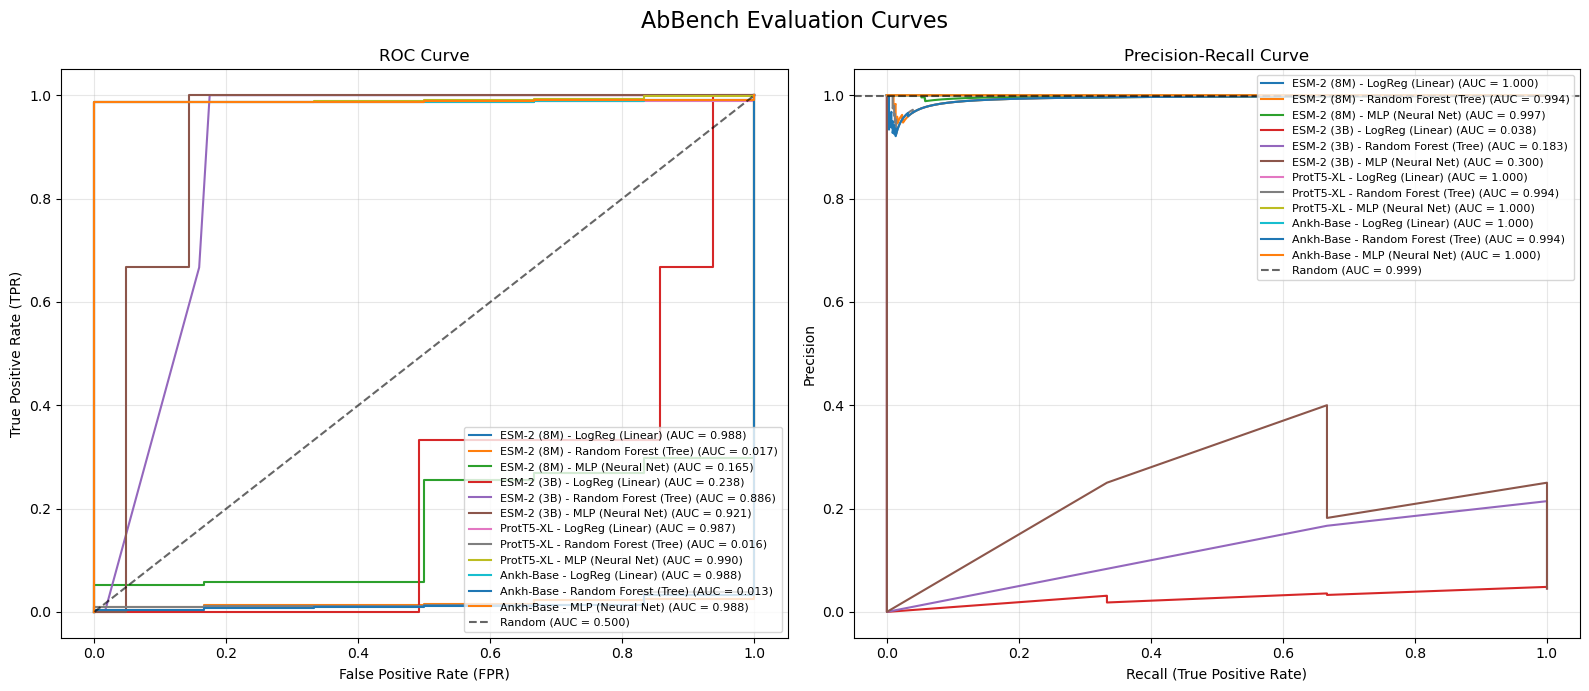

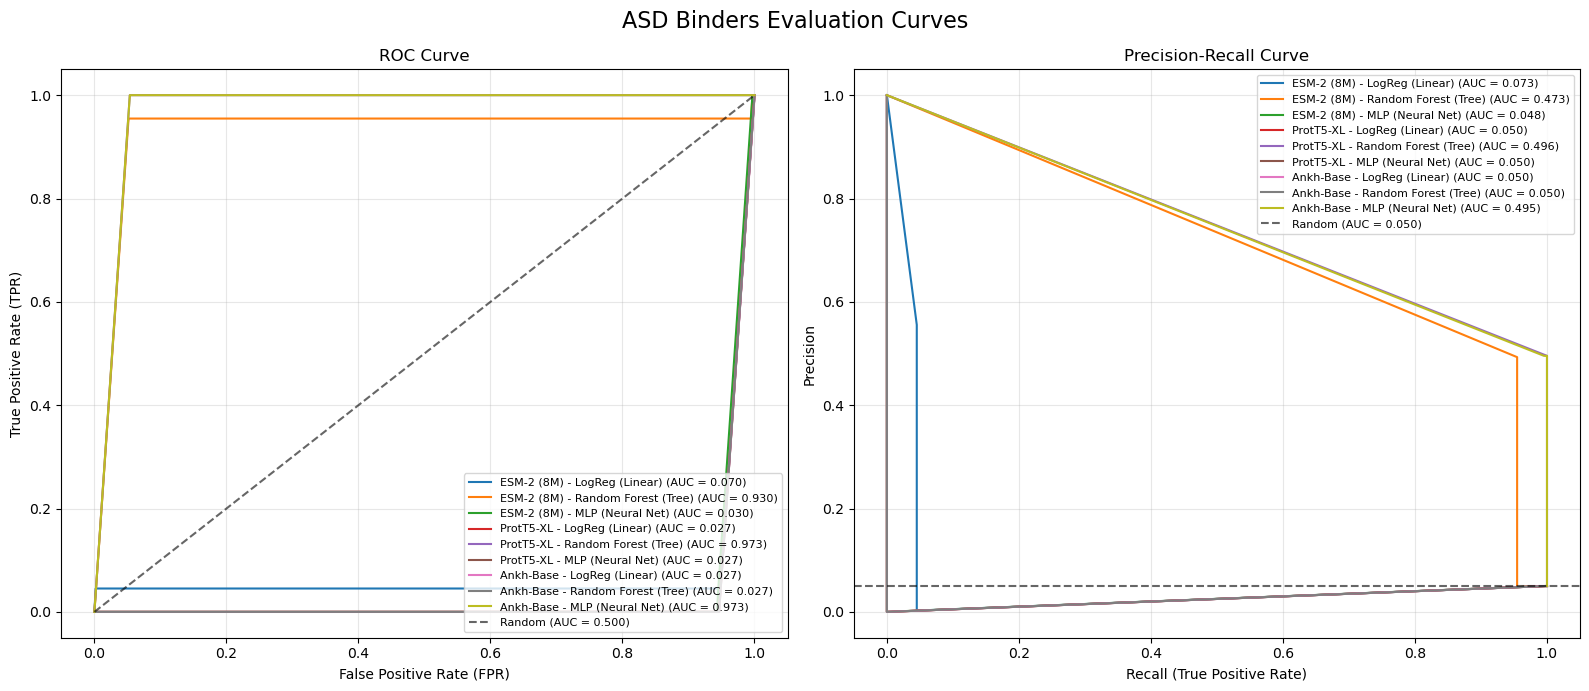

In [10]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

output_dir = "evaluation_outputs"
df_meta = pd.read_csv(os.path.join(output_dir, "abag_full_dataset.csv"))

classifiers = {
    "LogReg (Linear)": LogisticRegression(
        max_iter=2000, class_weight='balanced'
    ),
    "Random Forest (Tree)": RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42
    ),
    "MLP (Neural Net)": MLPClassifier(
        hidden_layer_sizes=(256, 64), max_iter=500, early_stopping=True, random_state=42
    )
}

def evaluate_embeddings(file_path, plm_name):
    if not os.path.exists(file_path): 
        print(f"Skipping {plm_name}: Data not found at {file_path}")
        return [], [], [], []
        
    with open(file_path, "rb") as f: 
        data = pickle.load(f)
    X, y = np.array(data["embeddings"]), np.array(data["labels"])
    
    # 1. Print encoded vector dimensionality
    dim = X.shape[1] if len(X.shape) > 1 else 0
    print(f"\n[*] {plm_name} Loaded | Encoded Vector Dimensionality: {dim} dimensions")
    
    if np.isnan(X).any():
        print(f"Warning: {plm_name} contains NaNs. Replacing with zeros.")
        X = np.nan_to_num(X)

    # Align metadata subset length with actual embedding output length
    n_samples = len(X)
    df_subset = df_meta.iloc[:n_samples].copy()

    train_mask = (df_subset['split'] == 'train') & (np.arange(n_samples) < len(y))
    test_ab_mask = (df_subset['split'] == 'test') & (np.arange(n_samples) < len(y))
    test_asd_mask = (df_subset['split'] == 'test_asd') & (np.arange(n_samples) < len(y))

    X_train, y_train = X[train_mask], y[train_mask]
    X_test_ab, y_test_ab = X[test_ab_mask], y[test_ab_mask]
    X_test_asd, y_test_asd = X[test_asd_mask], y[test_asd_mask]
    
    if len(np.unique(y_train)) < 2:
        print(f"⚠️ Skipping evaluation for {plm_name}: Training set contains only one class.")
        return [], [], [], []
        
    y_test_ab = y_test_ab if len(np.unique(y_test_ab)) >= 2 else None
    y_test_asd = y_test_asd if len(np.unique(y_test_asd)) >= 2 else None
    
    if y_test_ab is None:
        print(f"⚠️ AbBench test set for {plm_name} contains only one class.")
    if y_test_asd is None:
        print(f"⚠️ ASD test set for {plm_name} contains only one class.")
        
    ab_results, asd_results = [], []
    ab_curves, asd_curves = [], []
    
    for clf_name, clf in classifiers.items():
        print(f"  -> Fitting {clf_name}...")
        
        # --- Dynamic Early Stopping Check ---
        if isinstance(clf, MLPClassifier):
            _, class_counts = np.unique(y_train, return_counts=True)
            if np.min(class_counts) < 2:
                print(f"   ⚠️ Rare class detected (< 2 samples in training). Disabling early_stopping for MLP.")
                clf.set_params(early_stopping=False)
            else:
                clf.set_params(early_stopping=True)

        clf.fit(X_train, y_train)
        
        # Helper function to process results for a specific test set
        def process_evaluation(X_test, y_test, dataset_name):
            y_proba = clf.predict_proba(X_test)[:, 1]
            
            # ROC and PR Curves data
            fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            roc_auc = roc_auc_score(y_test, y_proba)
            pr_auc = average_precision_score(y_test, y_proba)
            
            # Calculate Optimal Threshold (Youden's J statistic)
            optimal_idx = np.argmax(tpr - fpr)
            optimal_threshold = thresholds_roc[optimal_idx]
            
            # Predict using optimal threshold instead of default 0.5
            y_pred_opt = (y_proba >= optimal_threshold).astype(int)
            
            # Confusion Matrix Counts
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
            total_pos = tp + fn
            total_neg = tn + fp
            
            # Metrics
            bal_acc = balanced_accuracy_score(y_test, y_pred_opt)
            
            res_dict = {
                "PLM Encoder": plm_name,
                "Downstream Model": clf_name,
                "Threshold": round(optimal_threshold, 4),
                "Balanced Acc": round(bal_acc, 4),
                "ROC-AUC": round(roc_auc, 4),
                "PR-AUC (Discovery)": round(pr_auc, 4),
                "Total Positives": total_pos,
                "Total Negatives": total_neg,
                "TP": tp,
                "TN": tn,
                "FP (False Pos)": fp,
                "FN (False Neg)": fn
            }
            
            curve_dict = {
                "label": f"{plm_name} - {clf_name}",
                "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc,
                "prec": prec, "rec": rec, "pr_auc": pr_auc
            }
            return res_dict, curve_dict

        # 1. Evaluate on AbBench Test Set
        if y_test_ab is not None:
            res, cur = process_evaluation(X_test_ab, y_test_ab, "AbBench")
            ab_results.append(res)
            ab_curves.append(cur)
            
        # 2. Evaluate on ASD Test Set
        if y_test_asd is not None:
            res, cur = process_evaluation(X_test_asd, y_test_asd, "ASD")
            asd_results.append(res)
            asd_curves.append(cur)
            
    return ab_results, asd_results, ab_curves, asd_curves

models_to_eval = [
    (os.path.join(output_dir, "esm2_abag_full_results.pkl"), "ESM-2 (8M)"),
    (os.path.join(output_dir, "esm2_650m_abag_full_results.pkl"), "ESM-2 (650M)"),
    (os.path.join(output_dir, "esm2_3b_abag_full_results.pkl"), "ESM-2 (3B)"),
    (os.path.join(output_dir, "prott5_abag_full_results.pkl"), "ProtT5-XL"),
    (os.path.join(output_dir, "ankh_abag_full_results.pkl"), "Ankh-Base")
]

all_ab_results, all_asd_results = [], []
all_ab_curves, all_asd_curves = [], []

for path, name in models_to_eval:
    res_ab, res_asd, cur_ab, cur_asd = evaluate_embeddings(path, name)
    all_ab_results.extend(res_ab)
    all_asd_results.extend(res_asd)
    all_ab_curves.extend(cur_ab)
    all_asd_curves.extend(cur_asd)

# Calculate global random baselines
random_baseline_pr_auc_ab = df_meta[df_meta['split'] == 'test']['label'].mean()
random_baseline_pr_auc_asd = df_meta[df_meta['split'] == 'test_asd']['label'].mean()

# ==========================================
# Output Leaderboards
# ==========================================
if all_ab_results:
    df_ab_leaderboard = pd.DataFrame(all_ab_results).sort_values(by="PR-AUC (Discovery)", ascending=False)
    print("\n" + "=" * 130)
    print("🏆 1. AbBench Evaluation Leaderboard (In-Distribution Test Set) 🏆")
    print(f"🎲 Random Baseline PR-AUC: {round(random_baseline_pr_auc_ab, 4)}")
    print("-" * 130)
    print(df_ab_leaderboard.to_markdown(index=False))

if all_asd_results:
    df_asd_leaderboard = pd.DataFrame(all_asd_results).sort_values(by="PR-AUC (Discovery)", ascending=False)
    print("\n" + "=" * 130)
    print("🏆 2. ASD Binders Evaluation Leaderboard (Out-of-Distribution Test Set) 🏆")
    print(f"🎲 Random Baseline PR-AUC: {round(random_baseline_pr_auc_asd, 4)}")
    print("-" * 130)
    print(df_asd_leaderboard.to_markdown(index=False))

# ==========================================
# Plotting ROC and PR Curves
# ==========================================
def plot_evaluation_curves(curve_data, dataset_name, random_baseline_pr):
    if not curve_data:
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"{dataset_name} Evaluation Curves", fontsize=16)
    
    # Plot ROC Curves
    for item in curve_data:
        ax1.plot(item['fpr'], item['tpr'], label=f"{item['label']} (AUC = {item['roc_auc']:.3f})")
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random (AUC = 0.500)")
    ax1.set_xlabel('False Positive Rate (FPR)')
    ax1.set_ylabel('True Positive Rate (TPR)')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(alpha=0.3)
    
    # Plot PR Curves
    for item in curve_data:
        ax2.plot(item['rec'], item['prec'], label=f"{item['label']} (AUC = {item['pr_auc']:.3f})")
    ax2.axhline(y=random_baseline_pr, color='k', linestyle='--', alpha=0.6, label=f"Random (AUC = {random_baseline_pr:.3f})")
    ax2.set_xlabel('Recall (True Positive Rate)')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{dataset_name.lower().replace(' ', '_')}_curves.png"), dpi=300)
    plt.show()

# Generate the plots
print("\nGenerating ROC and PR AUC plots...")
plot_evaluation_curves(all_ab_curves, "AbBench", random_baseline_pr_auc_ab)
plot_evaluation_curves(all_asd_curves, "ASD Binders", random_baseline_pr_auc_asd)

# Step 4: Output results

# ADDITIONAL: GARBAGE COLLECTION
Run this to clear GPU memory if memory allocation errors exist after running some models

In [9]:
import torch
import gc

print("--- VRAM Purge ---")

# Delete any lingering global variables if they exist in the notebook namespace
for var_name in ['model', 'tokenizer', 'embeddings', 'outputs', 'inputs']:
    if var_name in globals():
        del globals()[var_name]

# Aggressive garbage collection
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    
    device_props = torch.cuda.get_device_properties(0)
    total_vram = device_props.total_memory / 1024**3
    allocated_vram = torch.cuda.memory_allocated() / 1024**3
    reserved_vram = torch.cuda.memory_reserved() / 1024**3
    free_vram = total_vram - reserved_vram
    
    print(f"VRAM After Purge: {allocated_vram*1024:.2f} MB allocated, {reserved_vram*1024:.2f} MB reserved")
    print(f"Free VRAM available: {free_vram:.2f} GB (Total capacity: {total_vram:.2f} GB)")

--- VRAM Purge ---
VRAM After Purge: 0.00 MB allocated, 0.00 MB reserved
Free VRAM available: 22.03 GB (Total capacity: 22.03 GB)


Program run is complete: YaY! Thank you for bearing with me for the (too long) duration of execution